In [2]:
from google.colab import files

uploaded = files.upload()

Saving dataset real zip.zip to dataset real zip.zip


In [5]:
import zipfile

with zipfile.ZipFile("dataset real zip.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [6]:
import os

print(os.listdir("/content/"))

['.config', 'dataset real zip.zip', 'dataset real', 'sample_data']


In [7]:
import os

print(os.listdir("/content/dataset real"))

['normal', 'stain', 'dent', 'scratch']


In [8]:
import tensorflow as tf

dataset_path = "/content/dataset real"

img_size = (128, 128)
batch_size = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 480 files belonging to 4 classes.
Using 384 files for training.
Found 480 files belonging to 4 classes.
Using 96 files for validation.


In [9]:
class_names = train_dataset.class_names

print(class_names)

['dent', 'normal', 'scratch', 'stain']


In [17]:
# Task 1: Problem Identification

problem_type = "Image Classification"

print("Problem Type:", problem_type)

print("\nExplanation:")

print("""
The dataset represents an Image Classification problem.

The dataset contains four classes:
- dent
- normal
- scratch
- stain

Each image belongs to exactly one category.

The goal of the CNN model is to analyze the image and predict
the correct class label based on visual patterns.

This is not:
- Object Detection -> because there are no bounding boxes
- Semantic Segmentation -> because pixels are not segmented
- Instance Segmentation -> because individual object masks are not provided

Therefore, Image Classification is the most appropriate computer vision problem type for this dataset.
""")

Problem Type: Image Classification

Explanation:

The dataset represents an Image Classification problem.

The dataset contains four classes:
- dent
- normal
- scratch
- stain

Each image belongs to exactly one category.

The goal of the CNN model is to analyze the image and predict
the correct class label based on visual patterns.

This is not:
- Object Detection -> because there are no bounding boxes
- Semantic Segmentation -> because pixels are not segmented
- Instance Segmentation -> because individual object masks are not provided

Therefore, Image Classification is the most appropriate computer vision problem type for this dataset.



In [19]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

In [20]:
dataset_path = "/content/dataset real"

In [21]:
classes = os.listdir(dataset_path)

print("Classes in Dataset:")
print(classes)

print("Number of Classes:", len(classes))

Classes in Dataset:
['normal', 'stain', 'dent', 'scratch']
Number of Classes: 4


In [22]:
print("Number of Images Per Class:\n")

for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):

        count = len(os.listdir(class_path))

        print(f"{class_name}: {count} images")

Number of Images Per Class:

normal: 120 images
stain: 120 images
dent: 120 images
scratch: 120 images


In [23]:
image_counts = []

for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):

        count = len(os.listdir(class_path))

        image_counts.append(count)

if len(set(image_counts)) == 1:

    print("Dataset is balanced")

else:

    print("Dataset is imbalanced")

Dataset is balanced


In [24]:
sample_class = classes[0]

sample_image = os.listdir(os.path.join(dataset_path, sample_class))[0]

img_path = os.path.join(dataset_path, sample_class, sample_image)

img = Image.open(img_path)

print("Image Dimensions:", img.size)

Image Dimensions: (96, 96)


In [25]:
img_size = (128, 128)
batch_size = 32

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=img_size,
    batch_size=batch_size
)

class_names = dataset.class_names

Found 480 files belonging to 4 classes.


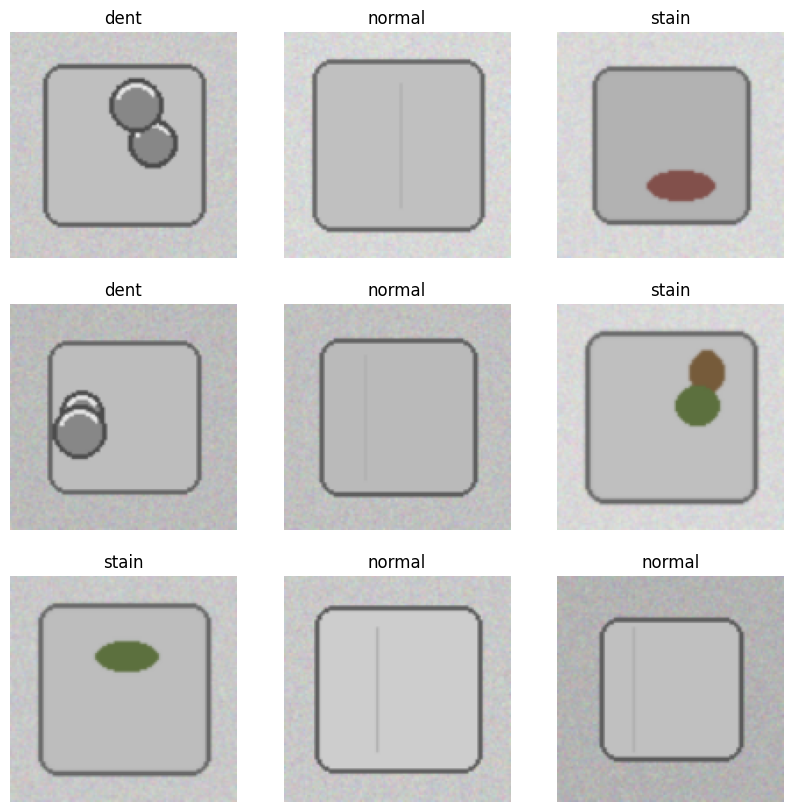

In [26]:
plt.figure(figsize=(10,10))

for images, labels in dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

task 3

In [27]:
import tensorflow as tf
from tensorflow.keras import layers

In [28]:
dataset_path = "/content/dataset real"

In [29]:
img_size = (128, 128)

batch_size = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 480 files belonging to 4 classes.
Using 384 files for training.
Found 480 files belonging to 4 classes.
Using 96 files for validation.


In [30]:
normalization_layer = layers.Rescaling(1./255)


In [31]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1)
])

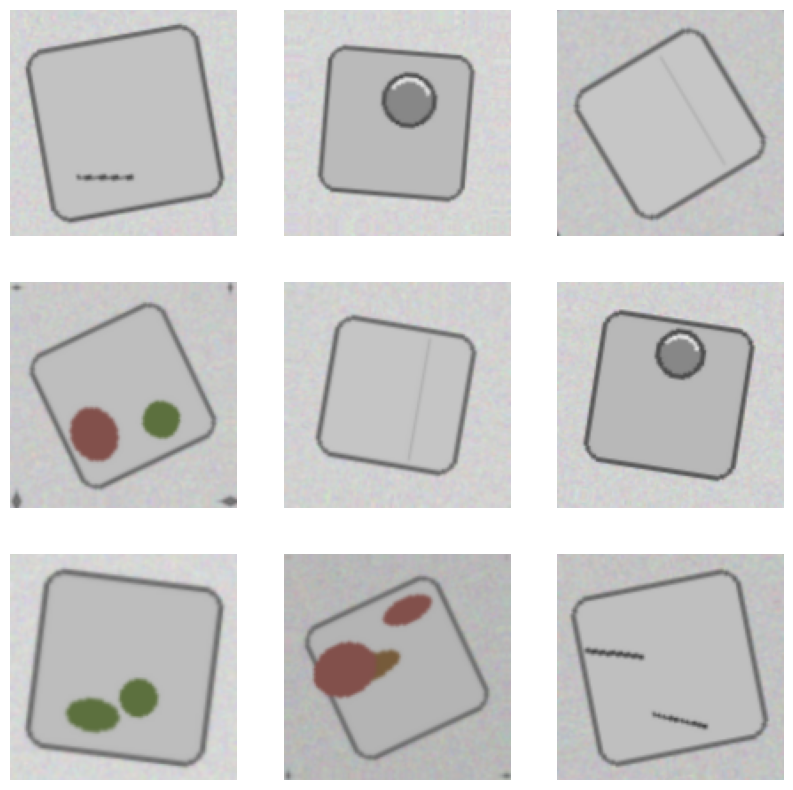

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    augmented_images = data_augmentation(images)

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(augmented_images[i].numpy().astype("uint8"))

        plt.axis("off")

plt.show()

task 4

In [33]:
from tensorflow.keras import layers, models

In [34]:
model = models.Sequential([

    # Normalization Layer
    layers.Rescaling(1./255, input_shape=(128,128,3)),


    # First Convolution Layer
    layers.Conv2D(32, (3,3), activation='relu'),


    # First Pooling Layer
    layers.MaxPooling2D(),


    # Second Convolution Layer
    layers.Conv2D(64, (3,3), activation='relu'),


    # Second Pooling Layer
    layers.MaxPooling2D(),


    # Third Convolution Layer
    layers.Conv2D(128, (3,3), activation='relu'),


    # Third Pooling Layer
    layers.MaxPooling2D(),


    # Flatten Layer
    layers.Flatten(),


    # Dense Layer
    layers.Dense(128, activation='relu'),


    # Output Layer
    layers.Dense(4, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [35]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

The CNN model consists of multiple convolution and pooling layers for feature extraction, followed by dense layers for classification.

In [36]:
model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

In [37]:
history = model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=10

)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.3073 - loss: 1.5883 - val_accuracy: 0.2917 - val_loss: 1.3843
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.3385 - loss: 1.3829 - val_accuracy: 0.2604 - val_loss: 1.3751
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.2995 - loss: 1.3493 - val_accuracy: 0.2917 - val_loss: 1.2902
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.4531 - loss: 1.2032 - val_accuracy: 0.4062 - val_loss: 1.0845
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5677 - loss: 0.9956 - val_accuracy: 0.4167 - val_loss: 1.0709
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6667 - loss: 0.8470 - val_accuracy: 0.6667 - val_loss: 0.7427
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7422 - loss: 0.6180 - val_accuracy: 0.8229 - val_loss: 0.6054
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8620 - loss: 0.4755 - val_accuracy: 0.8021 - val_loss:

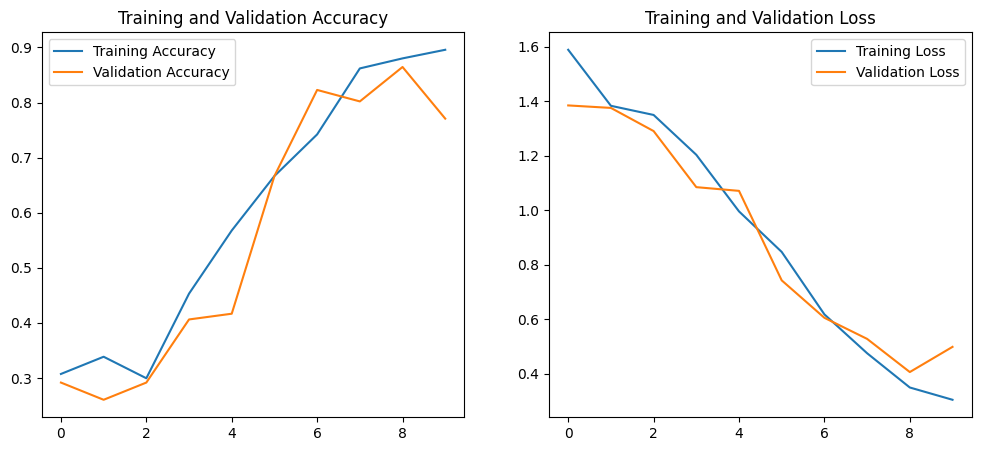

In [38]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(10)

plt.figure(figsize=(12,5))


# Accuracy Graph
plt.subplot(1,2,1)

plt.plot(epochs_range, acc, label='Training Accuracy')

plt.plot(epochs_range, val_acc, label='Validation Accuracy')

plt.legend()

plt.title('Training and Validation Accuracy')


# Loss Graph
plt.subplot(1,2,2)

plt.plot(epochs_range, loss, label='Training Loss')

plt.plot(epochs_range, val_loss, label='Validation Loss')

plt.legend()

plt.title('Training and Validation Loss')

plt.show()

In [39]:
test_loss, test_accuracy = model.evaluate(val_dataset)

print("Testing Accuracy:", test_accuracy)

print("Testing Loss:", test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step - accuracy: 0.7708 - loss: 0.4989
Testing Accuracy: 0.7708333134651184
Testing Loss: 0.49885237216949463


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step


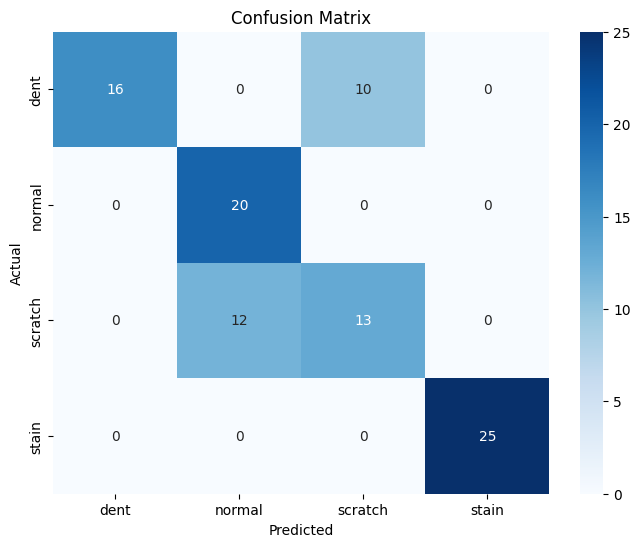

In [40]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_dataset:

    predictions = model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


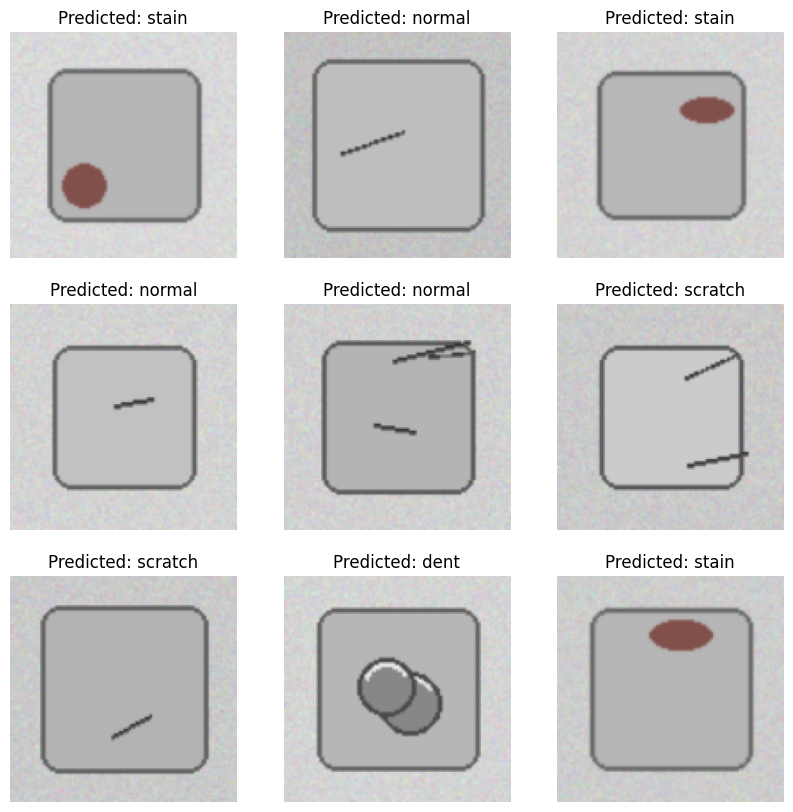

In [41]:
plt.figure(figsize=(10,10))

for images, labels in val_dataset.take(1):

    predictions = model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(
            f"Predicted: {class_names[predicted_labels[i]]}"
        )

        plt.axis("off")

plt.show()